# Fake News Detection - 01 Preprocessing



## Task 1 - Small sample

In [1]:
import os
import sys

sys.path.insert(0, '../src')

import polars as pl

from preprocessing import natural_language_cols, preprocess, preprocess_file

In [2]:
df_sample = pl.read_csv('../data/raw/news_sample.csv', n_rows=250)
df_sample.select(natural_language_cols).head()

content,title,authors,meta_keywords,meta_description
str,str,str,str,str
"""Sometimes the power of Christm…","""Church Congregation Brings Gif…","""Ruth Harris""","""['']""",null
"""AWAKENING OF 12 STRANDS of DNA…","""AWAKENING OF 12 STRANDS of DNA…","""Zurich Times""","""['']""",null
"""Never Hike Alone: A Friday the…","""Never Hike Alone - A Friday th…",null,"""['']""","""Never Hike Alone: A Friday the…"
"""When a rare shark was caught, …","""Elusive ‘Alien Of The Sea ‘ Ca…","""Alexander Smith""","""['']""",null
"""Donald Trump has the unnerving…","""Trump’s Genius Poll Is Complet…","""Gloria Christie""","""['']""",null


In [3]:
df_clean = preprocess(df_sample)
df_clean.select(natural_language_cols).head()

content,title,authors,meta_keywords,meta_description
str,str,str,str,str
"""sometim power christma make wi…","""church congreg bring gift wait…","""ruth harri""","""""",null
"""awaken <num> strand dna reconn…","""awaken <num> strand dna reconn…","""zurich time""","""""",null
"""never hike alon friday <num> t…","""never hike alon - friday <num>…",null,"""""","""never hike alon friday <num> t…"
"""rare shark caught scientist le…","""elus alien sea caught scientis…","""alexand smith""","""""",null
"""donald trump unnerv abil abil …","""trump geniu poll complet resul…","""gloria christi""","""""",null


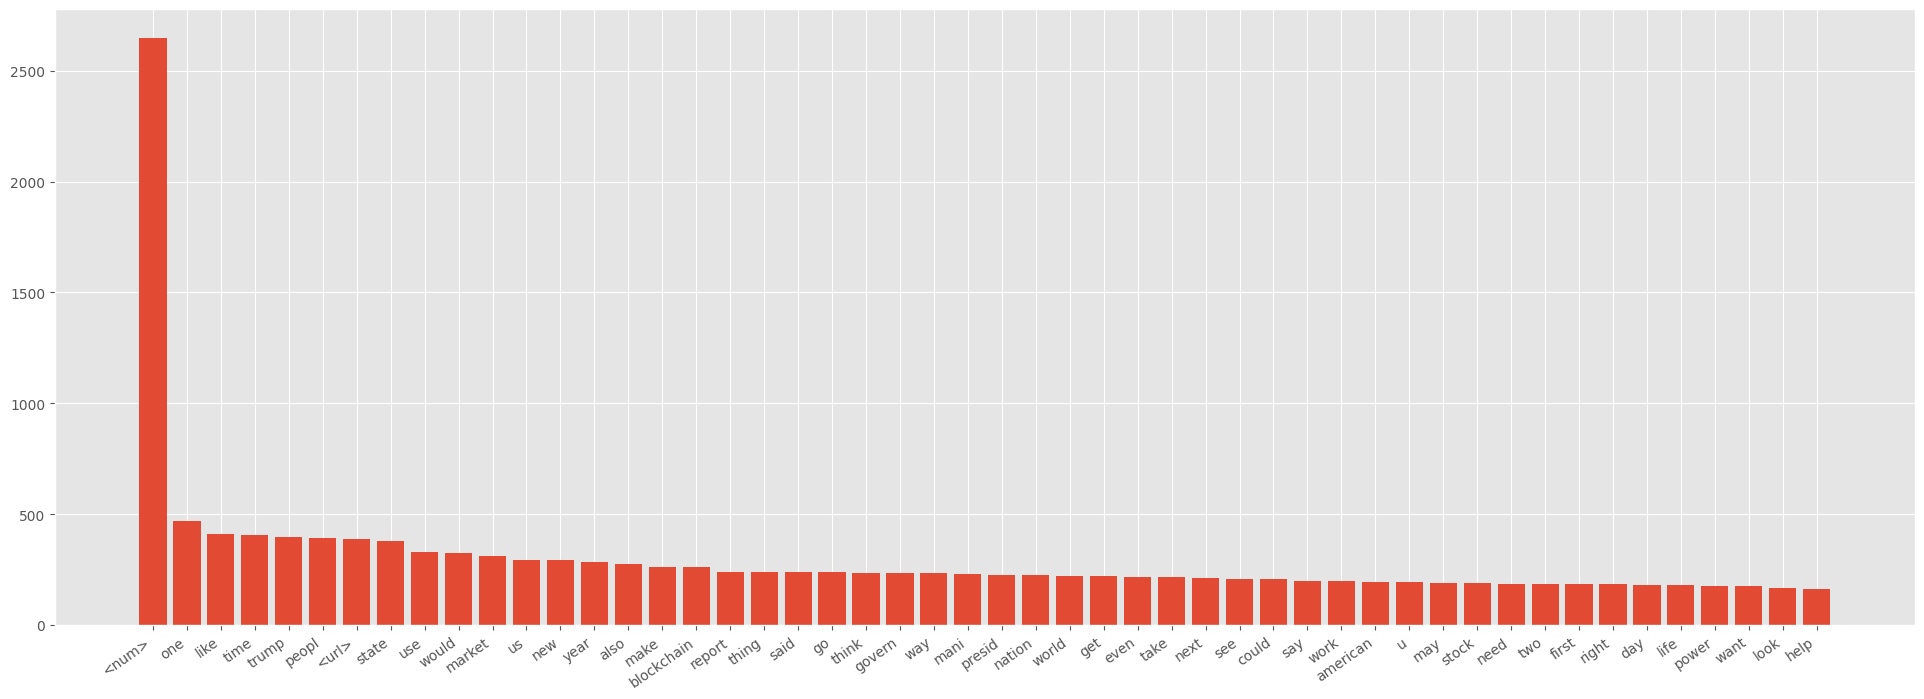

In [4]:
from collections import Counter
import matplotlib.pyplot as plt
plt.style.use("ggplot")
# Make Zipf's law plot of the 50 most common tokens after preprocessing
# Gather all text from NL columns, split into tokens, count

all_text = " ".join(
    df_clean.select(natural_language_cols)
    .fill_null("")
    .unpivot()
    .get_column("value")
    .to_list()
)

token_counts = Counter(all_text.split())
most_common = token_counts.most_common(50)
words, counts = zip(*most_common)

plt.figure(figsize=(24, 8))
plt.bar(list(words), list(counts))
plt.xticks(rotation=35, ha="right")
plt.show()

## Task 2 - Bigger subset

In [5]:
raw_file = '../data/raw/995,000_rows.csv'
preprocessed_file = '../data/preprocessed/995,000_rows_preprocessed.csv'
preprocessed_file

'../data/preprocessed/995,000_rows_preprocessed.csv'

In [6]:
# preprocess_file(
#     filepath=raw_file,
#     outpath=preprocessed_file,
#     chunk_size=50_000,
# )

## Task 3 - Exploration

In [7]:
import pandas as pd

df = pl.read_csv(preprocessed_file)
df

domain,type,url,content,scraped_at,inserted_at,updated_at,title,authors,meta_keywords,meta_description,tags,source
str,str,str,str,str,str,str,str,str,str,str,str,str
"""nationalreview.com""","""political""","""http://www.nationalreview.com/…","""plus one articl googl plus tha…","""2017-11-27T01:14:42.983556""","""2018-02-08 19:18:34.468038""","""2018-02-08 19:18:34.468066""","""iran news round""","""nan""","""nation review nation review on…","""nan""","""nan""","""nan"""
"""beforeitsnews.com""","""fake""","""http://beforeitsnews.com/econo…","""cost best senat bank committe …","""2017-11-27T01:14:08.7454""","""2018-02-08 19:18:34.468038""","""2018-02-08 19:18:34.468066""","""cost best senat bank committe …","""nan""","""nan""","""nan""","""nan""","""nan"""
"""dailycurrant.com""","""satire""","""http://dailycurrant.com/2016/0…","""man awoken <NUM> -year coma co…","""2017-11-27T01:14:21.395055""","""2018-02-07 23:39:33.852671""","""2018-02-07 23:39:33.852696""","""man awoken <NUM> -year coma co…","""nan""","""nan""","""nan""","""nan""","""nan"""
"""nytimes.com""","""reliable""","""https://query.nytimes.com/gst/…","""julia geist ask draw pictur co…","""2018-02-11 00:46:42.632962""","""2018-02-11 00:14:20.346838""","""2018-02-11 00:14:20.346871""","""open gateway girl enter comput…","""nan""","""comput internet women girl car…","""julia geist ask draw pictur co…","""nan""","""nytimes"""
"""infiniteunknown.net""","""conspiracy""","""http://www.infiniteunknown.net…","""<NUM> compil studi vaccin dang…","""2017-11-10T11:18:44.524042""","""2018-02-07 23:39:33.852671""","""2018-02-07 23:39:33.852696""","""<NUM> compil studi vaccin dang…","""nan""","""nan""","""nan""","""Lymphoma, Hepatitis B, Immune …","""nan"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""21stcenturywire.com""","""conspiracy""","""http://21stcenturywire.com/tag…","""<NUM> wire intervent watch say…","""2017-11-09T12:48:34.461199""","""2018-02-07 23:39:33.852671""","""2018-02-07 23:39:33.852696""","""koni <NUM> archiv""","""nan""","""nan""","""nan""","""Michelle Obama, Drones, Selfie…","""nan"""
"""nationalreview.com""","""political""","""http://www.nationalreview.com/…","""plus one articl googl plus tha…","""2017-11-27T01:14:42.983556""","""2018-02-08 19:18:34.468038""","""2018-02-08 19:18:34.468066""","""iran news round""","""nan""","""nation review nation review on…","""nan""","""nan""","""nan"""
"""thesaker.is""","""unknown""","""http://thesaker.is/china-and-r…","""china russia acquir gold dump …","""2017-11-18T20:01:27.400599""","""2018-02-07 23:39:33.852671""","""2018-02-07 23:39:33.852696""","""china russia acquir gold dump …","""saker""","""nan""","""bird eye view vineyard""","""Gold, Dollar, Russia, China""","""nan"""


In [8]:
# # 1. counting the number of URLs in the content
# vocab = {}
# for idx,col in enumerate(natural_language_cols):
#     sys.stdout.write(f'\rCols: {idx+1}/{len(natural_language_cols)}')
#     for cell in df[col]:
#         for w in cell.split():
#             if w in vocab:
#                 vocab[w] += 1
#             else:
#                 vocab[w] = 1

# vocab = {k:val for k,val in sorted(vocab.items(), key=lambda item: item[1], reverse=True)}
# vocab = pd.DataFrame({'token': list(vocab.keys()), 'count': list(vocab.values())}).set_index('token')
# vocab = vocab[vocab.reset_index()['token'].apply(lambda x: len(x) <= 30).values].reset_index()
# vocab.head(30)

In [9]:
# top_vocab = vocab.head(100)
# plt.figure(figsize=(32,12))
# plt.bar(top_vocab.index, top_vocab['count'])
# plt.xticks(rotation=35, ha='right')
# plt.show()

In [10]:
# special_tokens = ['<URL>','<EMAIL>','<DATE>','<NUM>']
# vocab[vocab['token'].apply(lambda x: x in special_tokens).values]

In [11]:
# # The percentage of unique tokens in the vocabulary that contain a hyphen
# print(float(vocab['token'].apply(lambda x : '-' in x).sum() / vocab.shape[0]) * 100.0)
# vocab[vocab['token'].apply(lambda x : '-' in x).values].head(30)

In [12]:
# # The percentage of total token usage (by count/frequency) that comes from hyphen-containing tokens 
# float(vocab[vocab['token'].apply(lambda x : '-' in x).values]['count'].sum() / vocab['count'].sum()) * 100.0

## Non-Trivial Discoveries

### 1. Urban Words
As it turns out, simply by looking at the 100 most common non-stopwords, we see that a lot of them are related to the so-called "urban" lifestyle. We may consider the following clusters:
- Geographical: 'world', 'states', 'york', 'countri', 'nation', 'citi'
- Political: 'govern', 'trump', 'obama', 'democrat', 'republican', 'war', 'leader', 'mr', 'presid', 'system', 'elect'
- Temporal: 'time', 'new', 'first', 'year', 'week', 'night'
- Journalism: 'news', 'report', 'stori'
- Corporate: 'compani', 'million', 'made', 'make', 'offic', 'read', 'law', 'plan'
- Health & Home: 'health', 'house', 'live', 'see'

### 2. Combining Words
Lots of words were combinations of other words using dashes ("-"). This seems pretty surprising, as most of the time, dash-words seem quite uncommon, but in the million articles, words containing dashes made up $30.13\%$ of words in the vocabulary, despite only making up $1.592\%$ of words used in general, which is still quite substantial. <br>
Here, the top-words containing dashes were words like "x-year-old", "e-mail", "long-term", "so-called",  and other more political ones like "iran-iraq", "pre-islam", "re-elect", "re-entry", "white-list", "same-sex", "anti-semit", "presedent-elect", "right-wing".

### 3. Letter placements
One of the noteworthy things about having access to a news-corpus of this magnitude, is that it allows you to study language and word-use as a whole. This means we have a great opportunity to answer interesting questions related to letter-use in the English language. In psychology-class, I remembered a study by Daniel Kahneman and Amos Tversky highlighting the availability bias. <br><br> They would do this by asking so-called "free-thinkers", whether English words were more likely to start with the letter "k" or to contain "k" as the third letter. In the study, most participants would answer the former, naming words like "king", "knee", "kid", "kick", but Tversky and Kahneman argued that "k" was actually more common as a third-letter because of words like "acknowledge","cake","makeover". Many of the participants would "forget the fact that "k" is a very common third-letter", because it's not as readily available in ones mind. I however, believe that "k" is more common as the fourth letter, as when paired up with a consonant, a vowel and a "c", you get words such as "hacker", "luck", "lock", "duck", "lick", "backpack". <br><br> I wanted to investigate this for myself, so I counted the distribution of positions for every letter using our vocabulary.

In [13]:
# # distribution over letter-positions
# letters = ' '.join('abcdefghijklmnopqrstuvwxyz-').split()
# pos_counts = {l: 10*[0] for l in letters}

# for _,(token,count) in vocab.iterrows():
#     for idx,letter in enumerate(token[:10]):
#         if letter in pos_counts:
#             pos_counts[letter][idx] += count

# pos_counts = pd.DataFrame(pos_counts, index=list(range(1,11))).transpose()
# pos_counts

In [14]:
# # first we rank the letters based on highest frequency to actually find most common letter rankings
# from codecs import ignore_errors
# letter_freqs = pos_counts.sum(1).sort_values(ascending=False)
# plt.figure(figsize=(24,8))
# plt.bar(letter_freqs.index, letter_freqs.values)
# plt.show()

In [15]:
# for l in letters:
#     pos_counts.loc[l].plot(kind='bar', figsize=(16,4))
#     plt.xticks(rotation=0)
#     plt.xlabel(f'position of {l}')
#     plt.ylabel('frequency')
    
#     plt.show()

### Overview
From this investigation, we can conclude many interesting and surprising results.

- We observed that Tversky and Kahneman were in fact **wrong**, as $k$ appeared more than twice as frequently in the fourth position as in the first, while only appearing slightly more commonly in the third position.

- Another surprising result is that $e,a$ are in fact the most frequently used letters, meaning when playing hangman, they should actually be your first guesses.

- Very surprisingly, the letter $z$ appears almost as frequently in the 7'th position as in the first. It also appeared the most frequently in the 3rd, 4th, and 5th positions.

## Task 4 - Split

In [16]:
# Unique labels
df['type'].unique()

type
str
"""political"""
"""junksci"""
"""reliable"""
"""clickbait"""
"""2018-02-10 13:43:39.521661"""
…
"""rumor"""
"""unknown"""
"""bias"""


We chose to exclude "unknown", "nan" and "2018-02-10 13:43:39.521661" from our labels.
And used "reliable" as real and the rest as "fake".

In [18]:
from data import standard_labels, split_data

df = pl.read_csv(preprocessed_file)
df = standard_labels(df)
split_data(df)

(shape: (722_943, 14)
 ┌────────────┬───────────┬────────────┬────────────┬───┬────────────┬────────────┬─────────┬───────┐
 │ domain     ┆ type      ┆ url        ┆ content    ┆ … ┆ meta_descr ┆ tags       ┆ source  ┆ label │
 │ ---        ┆ ---       ┆ ---        ┆ ---        ┆   ┆ iption     ┆ ---        ┆ ---     ┆ ---   │
 │ str        ┆ str       ┆ str        ┆ str        ┆   ┆ ---        ┆ str        ┆ str     ┆ str   │
 │            ┆           ┆            ┆            ┆   ┆ str        ┆            ┆         ┆       │
 ╞════════════╪═══════════╪════════════╪════════════╪═══╪════════════╪════════════╪═════════╪═══════╡
 │ nytimes.co ┆ reliable  ┆ https://ww ┆ staci rena ┆ … ┆ nan        ┆ nan        ┆ nytimes ┆ real  │
 │ m          ┆           ┆ w.nytimes. ┆ johnson    ┆   ┆            ┆            ┆         ┆       │
 │            ┆           ┆ com/2003/0 ┆ michael    ┆   ┆            ┆            ┆         ┆       │
 │            ┆           ┆ …          ┆ bri…       ┆   ┆   